# Layer-wise Self-Distillation with ResNet18

This notebook demonstrates how to construct a layer-wise self-distillation model using PyTorch with ResNet18 backbone and pretrained weights from a checkpoint.

In [14]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
from pathlib import Path
from typing import List, Tuple, Dict, Optional
import lightning.pytorch as pl

# Check device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## Define Layer-wise Self-Distillation Components

Layer-wise self-distillation works by:
- Extracting intermediate features from different layers of the network
- Using these intermediate features to provide supervision signals during training
- This regularization technique improves generalization and robustness

In [15]:
class FeatureExtractor(nn.Module):
    """
    Module to extract intermediate features from specific layers.
    Used to capture activations at different depths in the network.
    """
    def __init__(self, model: nn.Module, layer_names: List[str]):
        super().__init__()
        self.model = model
        self.layer_names = layer_names
        self.features = {}
        self.hooks = []
        self._register_hooks()
    
    def _register_hooks(self):
        """Register forward hooks to capture intermediate features."""
        def get_hook(name):
            def hook(module, input, output):
                if isinstance(output, torch.Tensor):
                    self.features[name] = output.detach()
                elif isinstance(output, tuple):
                    self.features[name] = output[0].detach() if isinstance(output[0], torch.Tensor) else output
            return hook
        
        for name, module in self.model.named_modules():
            if name in self.layer_names:
                hook = module.register_forward_hook(get_hook(name))
                self.hooks.append(hook)
    
    def forward(self, x: torch.Tensor) -> Tuple[torch.Tensor, Dict[str, torch.Tensor]]:
        """
        Forward pass and return output plus intermediate features.
        
        Args:
            x: Input tensor
            
        Returns:
            Tuple of (output, features_dict)
        """
        self.features.clear()
        output = self.model(x)
        return output, self.features
    
    def remove_hooks(self):
        """Remove all registered hooks."""
        for hook in self.hooks:
            hook.remove()


class LayerWiseDistillationLoss(nn.Module):
    """
    Computes layer-wise distillation loss.
    Distills knowledge from deeper layers to shallower layers.
    """
    def __init__(self, hidden_dim: int = 256, temperature: float = 4.0, alpha: float = 0.5):
        super().__init__()
        self.temperature = temperature
        self.alpha = alpha  # Weight for KD loss vs classification loss
        self.hidden_dim = hidden_dim
        
        # Projection heads to project different feature dimensions to same space
        # These will be initialized dynamically in ResNet18LayerWiseDistillation
        self.shallow_proj = None
        self.deep_proj = None
    
    def set_projections(self, shallow_dim: int, deep_dim: int):
        """Initialize projection layers based on input dimensions."""
        if self.shallow_proj is None:
            self.shallow_proj = nn.Sequential(
                nn.Linear(shallow_dim, self.hidden_dim),
                nn.ReLU(),
                nn.Linear(self.hidden_dim, self.hidden_dim)
            )
            self.deep_proj = nn.Sequential(
                nn.Linear(deep_dim, self.hidden_dim),
                nn.ReLU(),
                nn.Linear(self.hidden_dim, self.hidden_dim)
            )
    
    def forward(self, 
                shallow_features: torch.Tensor, 
                deep_features: torch.Tensor,
                logits: torch.Tensor,
                targets: torch.Tensor) -> Tuple[torch.Tensor, Dict[str, torch.Tensor]]:
        """
        Compute layer-wise knowledge distillation loss.
        
        Args:
            shallow_features: Features from shallower layers (student) [B, C1]
            deep_features: Features from deeper layers (teacher) [B, C2]
            logits: Classification logits [B, num_classes]
            targets: Ground truth labels [B]
            
        Returns:
            Tuple of (total_loss, loss_dict)
        """
        # Classification loss
        ce_loss = F.cross_entropy(logits, targets)
        
        # Ensure features are flattened to [B, C]
        shallow_feat = shallow_features.view(shallow_features.size(0), -1)
        deep_feat = deep_features.view(deep_features.size(0), -1)
        
        # Initialize projections if needed
        if self.shallow_proj is None:
            self.set_projections(shallow_feat.size(1), deep_feat.size(1))
            # Move to same device as input
            self.shallow_proj = self.shallow_proj.to(shallow_feat.device)
            self.deep_proj = self.deep_proj.to(deep_feat.device)
        
        # Project features to same dimension
        shallow_proj = self.shallow_proj(shallow_feat)
        deep_proj = self.deep_proj(deep_feat)
        
        # Normalize projected features
        shallow_norm = F.normalize(shallow_proj, p=2, dim=1)
        deep_norm = F.normalize(deep_proj, p=2, dim=1)
        
        # MSE loss between normalized features encourages alignment
        feature_mse = F.mse_loss(shallow_norm, deep_norm)
        
        # Cosine similarity as a regularization term
        cosine_sim = F.cosine_similarity(shallow_proj, deep_proj, dim=1).mean()
        
        # KD loss: Combine MSE and encourage positive cosine similarity
        kd_loss = feature_mse * (1 - torch.clamp(cosine_sim, min=0))
        
        # Total loss
        total_loss = (1 - self.alpha) * ce_loss + self.alpha * kd_loss
        
        return total_loss, {
            'ce_loss': ce_loss.item(),
            'kd_loss': kd_loss.item(),
            'total_loss': total_loss.item()
        }


class ResNet18LayerWiseDistillation(nn.Module):
    """
    ResNet18 with layer-wise self-distillation.
    Extracts features from multiple layers and applies distillation loss between them.
    """
    def __init__(self, num_classes: int = 200, pretrained: bool = False, hidden_dim: int = 256):
        super().__init__()
        
        # Load base ResNet18
        self.backbone = models.resnet18(pretrained=pretrained)
        
        # Define layers to extract features from (at different depths)
        self.feature_layers = [
            'layer1',      # First residual block (64 channels)
            'layer2',      # Second residual block (128 channels) 
            'layer3',      # Third residual block (256 channels)
            'layer4',      # Fourth residual block (512 channels)
        ]
        
        self.num_classes = num_classes
        self.hidden_dim = hidden_dim
        self.feature_extractor = FeatureExtractor(self.backbone, self.feature_layers)
        
        # Classifier head
        num_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Linear(num_features, num_classes)
        
        # Distillation loss with projection heads
        self.kd_loss_fn = LayerWiseDistillationLoss(hidden_dim=hidden_dim, temperature=4.0, alpha=0.5)
    
    def forward(self, x: torch.Tensor, targets: Optional[torch.Tensor] = None):
        """
        Forward pass with optional distillation loss computation.
        
        Args:
            x: Input tensor [B, 3, H, W]
            targets: Optional ground truth labels for distillation loss
            
        Returns:
            - If targets is None: logits [B, num_classes]
            - If targets is provided: (logits, loss_tensor, losses_dict) where loss_tensor has gradients
        """
        logits, layer_features = self.feature_extractor(x)
        
        if targets is None:
            return logits
        
        # Extract shallow (layer1) and deep (layer4) features
        shallow_feat = layer_features.get('layer1', None)
        deep_feat = layer_features.get('layer4', None)
        
        if shallow_feat is not None and deep_feat is not None:
            # Global average pooling to get [B, C] from [B, C, H, W]
            shallow_feat = F.adaptive_avg_pool2d(shallow_feat, (1, 1)).view(shallow_feat.size(0), -1)
            deep_feat = F.adaptive_avg_pool2d(deep_feat, (1, 1)).view(deep_feat.size(0), -1)
            
            total_loss, loss_dict = self.kd_loss_fn(shallow_feat, deep_feat, logits, targets)
            return logits, total_loss, loss_dict
        
        # Fallback to just classification loss if features unavailable
        ce_loss = F.cross_entropy(logits, targets)
        return logits, ce_loss, {'ce_loss': ce_loss.item(), 'kd_loss': 0.0, 'total_loss': ce_loss.item()}


## Load Pretrained Checkpoint and Extract ResNet18 Weights

In [16]:
# Path to the pretrained checkpoint
checkpoint_path = Path(r"D:\GitHub\noro-VL2Lite-experiment\logs\train\runs\2026-04-17_08-54-01\checkpoints\epoch_099.ckpt")

print(f"Loading checkpoint from: {checkpoint_path}")
print(f"Checkpoint exists: {checkpoint_path.exists()}")

# PyTorch 2.6+ requires adding custom classes to safe globals
# Import the custom classes from your project
import sys
sys.path.insert(0, r"D:\GitHub\noro-VL2Lite-experiment")

from src.models.components.campus import TeacherStudent, TeacherNet, StudentNet, ModifiedResNet, AlignNet
from src.models.kd_module import KDModule

# Add custom globals to PyTorch's safe list
torch.serialization.add_safe_globals([
    TeacherStudent, TeacherNet, StudentNet, ModifiedResNet, AlignNet, KDModule
])

# Load checkpoint using PyTorch Lightning format
checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)

# Inspect checkpoint structure
print("\nCheckpoint keys:")
for key in checkpoint.keys():
    print(f"  - {key}")

# The state_dict is usually under 'state_dict' key in Lightning checkpoints
if 'state_dict' in checkpoint:
    state_dict = checkpoint['state_dict']
    print(f"\nState dict contains {len(state_dict)} parameters")
    print("\nSample keys from state_dict:")
    for i, key in enumerate(list(state_dict.keys())[:10]):
        print(f"  - {key}: {state_dict[key].shape}")
else:
    state_dict = checkpoint
    print(f"\nState dict contains {len(state_dict)} parameters")

Loading checkpoint from: D:\GitHub\noro-VL2Lite-experiment\logs\train\runs\2026-04-17_08-54-01\checkpoints\epoch_099.ckpt
Checkpoint exists: True

Checkpoint keys:
  - epoch
  - global_step
  - pytorch-lightning_version
  - state_dict
  - loops
  - callbacks
  - optimizer_states
  - lr_schedulers
  - MixedPrecision
  - hparams_name
  - hyper_parameters
  - datamodule_hparams_name
  - datamodule_hyper_parameters

State dict contains 803 parameters

Sample keys from state_dict:
  - net.student.model.resnet.conv1.weight: torch.Size([64, 3, 7, 7])
  - net.student.model.resnet.bn1.weight: torch.Size([64])
  - net.student.model.resnet.bn1.bias: torch.Size([64])
  - net.student.model.resnet.bn1.running_mean: torch.Size([64])
  - net.student.model.resnet.bn1.running_var: torch.Size([64])
  - net.student.model.resnet.bn1.num_batches_tracked: torch.Size([])
  - net.student.model.resnet.layer1.0.conv1.weight: torch.Size([64, 64, 3, 3])
  - net.student.model.resnet.layer1.0.bn1.weight: torch.Size(

In [17]:
def extract_resnet_weights(state_dict: Dict, prefix: str = 'net.student.model.') -> Dict:
    """
    Extract ResNet18 weights from the checkpoint state dict.
    The checkpoint contains the full TeacherStudent model, but we only need the student ResNet.
    
    Args:
        state_dict: The checkpoint state_dict
        prefix: The prefix in the state_dict where ResNet weights are stored
        
    Returns:
        Dictionary with ResNet weights (with prefix removed)
    """
    resnet_weights = {}
    
    for key, value in state_dict.items():
        # Look for keys with the ResNet model prefix
        if key.startswith(prefix):
            # Remove prefix to get clean ResNet state dict
            clean_key = key[len(prefix):]
            resnet_weights[clean_key] = value
    
    return resnet_weights

# Extract ResNet18 weights - try different prefixes based on the architecture
possible_prefixes = [
    'net.student.model.resnet.',      # Standard TeacherStudent architecture
    'net.model.',              # Alternative prefix
    'student.model.',          # Alt 2
    'model.',                  # Alt 3
]

resnet_weights = {}
used_prefix = None

for prefix in possible_prefixes:
    candidate_weights = extract_resnet_weights(state_dict, prefix)
    if len(candidate_weights) > 0:
        resnet_weights = candidate_weights
        used_prefix = prefix
        print(f"✓ Found ResNet weights with prefix: '{prefix}'")
        print(f"  Extracted {len(resnet_weights)} parameters")
        break

if not resnet_weights:
    print("⚠ Could not find ResNet weights with standard prefixes.")
    print("Available state dict keys (showing first 20):")
    for key in list(state_dict.keys())[:20]:
        print(f"  - {key}")
else:
    # Show sample of extracted weights
    print(f"\nSample of extracted ResNet weights:")
    for key in list(resnet_weights.keys())[:5]:
        print(f"  - {key}: {resnet_weights[key].shape}")

✓ Found ResNet weights with prefix: 'net.student.model.resnet.'
  Extracted 120 parameters

Sample of extracted ResNet weights:
  - conv1.weight: torch.Size([64, 3, 7, 7])
  - bn1.weight: torch.Size([64])
  - bn1.bias: torch.Size([64])
  - bn1.running_mean: torch.Size([64])
  - bn1.running_var: torch.Size([64])


## Create and Initialize the Layer-wise Self-Distillation Model

In [18]:
# Create the layer-wise distillation model
# Assuming the checkpoint trained on 120 classes (Stanford Dogs dataset)
num_classes = 120

model = ResNet18LayerWiseDistillation(num_classes=num_classes, pretrained=False)
model = model.to(device)

print(f"Created ResNet18LayerWiseDistillation model with {num_classes} classes")
print(f"Model architecture:\n{model}")

# Load pretrained weights if we successfully extracted them
if resnet_weights:
    print(f"\nLoading {len(resnet_weights)} pretrained weights...")
    
    # Try to load the weights
    missing_keys, unexpected_keys = model.backbone.load_state_dict(resnet_weights, strict=False)
    
    if missing_keys:
        print(f"⚠ Missing keys ({len(missing_keys)}):")
        for key in missing_keys[:5]:
            print(f"  - {key}")
        if len(missing_keys) > 5:
            print(f"  ... and {len(missing_keys) - 5} more")
    
    if unexpected_keys:
        print(f"⚠ Unexpected keys ({len(unexpected_keys)}):")
        for key in unexpected_keys[:5]:
            print(f"  - {key}")
        if len(unexpected_keys) > 5:
            print(f"  ... and {len(unexpected_keys) - 5} more")
    
    if not missing_keys and not unexpected_keys:
        print("✓ All weights loaded successfully!")
else:
    print("⚠ Could not load pretrained weights. Using random initialization.")

Created ResNet18LayerWiseDistillation model with 120 classes
Model architecture:
ResNet18LayerWiseDistillation(
  (backbone): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), pa

## Summary and Configuration Guide

### Key Components:

1. **FeatureExtractor**: Captures intermediate features from specified layers (layer1-4)
2. **LayerWiseDistillationLoss**: Computes KL divergence between shallow and deep features
3. **ResNet18LayerWiseDistillation**: Full self-distillation model combining everything
4. **LayerWiseDistillationLightningModule**: Lightning wrapper for easy integration

### Configuration Parameters:

| Parameter | Default | Description |
|-----------|---------|-------------|
| `temperature` | 4.0 | Temperature for softening distributions (higher = softer) |
| `alpha` | 0.5 | Weight between CE loss (1-alpha) and KD loss (alpha) |
| `learning_rate` | 1e-4 | Adam optimizer learning rate |
| `num_classes` | 200 | Number of output classes |

### How Layer-wise Distillation Works:

1. Forward pass extracts features from layer1 (shallow) and layer4 (deep)
2. Features are normalized and passed through softmax
3. KL divergence loss pushes shallow features to match deep features
4. Combined with classification loss: `L_total = (1-α)L_CE + αL_KD`
5. This acts as regularization, improving generalization

### Integration with Your Project:

To use this in your Hydra config, create `configs/model/layer_wise_distillation.yaml`:

```yaml
_target_: src.models.components.layer_wise_distillation.LayerWiseDistillationLightningModule

num_classes: ${data.train_dataset.attributes.class_num}
learning_rate: 0.0001
temperature: 4.0
alpha: 0.5
pretrained_ckpt: /path/to/checkpoint.ckpt

# PyTorch compile for faster training
compile: false
```

### Next Steps:

1. Move the model classes to `src/models/components/layer_wise_distillation.py`
2. Update your data config to prepare dataloaders
3. Create a training config in `configs/` directory
4. Run training: `python src/train.py model=layer_wise_distillation`

## PyTorch Training Loop (without Lightning/Hydra)

This section provides a standalone training loop using only PyTorch, with the StanfordDogs dataset.


In [22]:
### 7a. Load StanfordDogs Dataset

import scipy.io as sio
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
import os
from PIL import Image
import numpy as np

class StanfordDogsDataset(Dataset):
    """
    Custom dataset loader for Stanford Dogs dataset.
    Uses train_list.mat and test_list.mat for train/test splits.
    """
    def __init__(self, dataset_path: str, split: str = 'train', transform=None):
        """
        Args:
            dataset_path: Path to the StanfordDogs dataset
            split: 'train' or 'test'
            transform: Image transforms to apply
        """
        self.dataset_path = Path(dataset_path)
        self.split = split
        self.transform = transform
        
        # Load image list from .mat file
        if split == 'train':
            mat_file = self.dataset_path / 'train_list.mat'
        else:
            mat_file = self.dataset_path / 'test_list.mat'
        
        print(f"Loading {split} list from: {mat_file}")
        mat_data = sio.loadmat(str(mat_file))
        
        # The .mat file contains file_list and labels
        # file_list is stored as a cell array of strings
        file_list = mat_data['file_list']
        labels = mat_data['labels'].flatten()
        
        # Convert cell array to list of strings
        self.image_paths = []
        self.labels = []
        
        for i, file_cell in enumerate(file_list):
            # Extract string from numpy array cell
            if isinstance(file_cell, np.ndarray):
                # Handle both regular arrays and 0-d arrays
                if file_cell.ndim == 0:
                    image_file = file_cell.item()
                elif len(file_cell) > 0:
                    image_file = file_cell[0]
                else:
                    image_file = None
            else:
                image_file = file_cell
            
            # Recursively handle nested numpy arrays
            while isinstance(image_file, np.ndarray):
                if image_file.ndim == 0:
                    image_file = image_file.item()
                else:
                    image_file = image_file[0] if len(image_file) > 0 else None
                    if image_file is None:
                        break
            
            if image_file is not None:
                # Handle both string and bytes
                if isinstance(image_file, bytes):
                    image_file = image_file.decode('utf-8')
                else:
                    image_file = str(image_file)
                
                full_path = self.dataset_path / 'Images' / image_file
                if full_path.exists():
                    self.image_paths.append(str(full_path))
                    self.labels.append(int(labels[i]) - 1)  # Convert to 0-indexed
        
        print(f"Loaded {len(self.image_paths)} images from {split} split")
        self.num_classes = len(np.unique(self.labels))
        print(f"Number of classes: {self.num_classes}")
    
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        image_path = self.image_paths[idx]
        label = self.labels[idx]
        
        # Load image
        image = Image.open(image_path).convert('RGB')
        
        if self.transform:
            image = self.transform(image)
        
        return image, label


# Define data transforms
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Create datasets
dataset_path = Path(r"D:\GitHub\noro-VL2Lite-experiment\data\kd_datasets\5_StanfordDogs")

print("Creating training dataset...")
train_dataset = StanfordDogsDataset(dataset_path, split='train', transform=train_transform)

print("\nCreating validation dataset...")
val_dataset = StanfordDogsDataset(dataset_path, split='test', transform=val_transform)

# Update model num_classes if different from 200
num_classes = train_dataset.num_classes
print(f"\n✓ Datasets ready. Total classes: {num_classes}")


Creating training dataset...
Loading train list from: D:\GitHub\noro-VL2Lite-experiment\data\kd_datasets\5_StanfordDogs\train_list.mat
Loaded 16418 images from train split
Number of classes: 120

Creating validation dataset...
Loading test list from: D:\GitHub\noro-VL2Lite-experiment\data\kd_datasets\5_StanfordDogs\test_list.mat
Loaded 4162 images from test split
Number of classes: 120

✓ Datasets ready. Total classes: 120


In [23]:
### 7b. Create DataLoaders

# Training parameters
batch_size = 16
# Use num_workers=0 in Jupyter notebooks to avoid multiprocessing hangs
# Set to > 0 only when running as a script
num_workers = 0

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    pin_memory=False  # Set to False when num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=False  # Set to False when num_workers=0
)

print(f"Train batches per epoch: {len(train_loader)}")
print(f"Val batches per epoch: {len(val_loader)}")
print(f"Total training samples: {len(train_dataset)}")
print(f"Total validation samples: {len(val_dataset)}")

# Test a batch
print("\n✓ Testing first batch...")
sample_batch = next(iter(train_loader))
images, labels = sample_batch
print(f"Batch shape: {images.shape}")
print(f"Labels shape: {labels.shape}")
print(f"Label values: {labels[:5]}")


Train batches per epoch: 1027
Val batches per epoch: 261
Total training samples: 16418
Total validation samples: 4162

✓ Testing first batch...
Batch shape: torch.Size([16, 3, 224, 224])
Labels shape: torch.Size([16])
Label values: tensor([118,  98,  16,  55,  97])


In [24]:
### 7c. Training Loop

from tqdm import tqdm
import time

# Training configuration
num_epochs = 100
learning_rate = 1e-4
weight_decay = 1e-5
warmup_epochs = 5

# Recreate model with correct number of classes
print(f"Creating model with {num_classes} classes...")
model = ResNet18LayerWiseDistillation(num_classes=num_classes, pretrained=False)
model = model.to(device)

# Load pretrained weights if available
if resnet_weights:
    print(f"Loading pretrained weights...")
    missing_keys, unexpected_keys = model.backbone.load_state_dict(resnet_weights, strict=False)
    if not missing_keys and not unexpected_keys:
        print("✓ All weights loaded successfully!")

# Optimizer and scheduler
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=1e-6)

# Warmup scheduler
def warmup_scheduler(epoch, base_lr, warmup_epochs):
    if epoch < warmup_epochs:
        return base_lr * (epoch + 1) / warmup_epochs
    return None

# Tracking
train_losses = []
val_losses = []
val_accs = []
best_val_acc = 0.0
checkpoint_dir = Path("checkpoints")
checkpoint_dir.mkdir(exist_ok=True)

print("=" * 60)
print(f"Starting training for {num_epochs} epochs")
print("=" * 60)

start_time = time.time()

for epoch in range(num_epochs):
    # Warmup phase
    if epoch < warmup_epochs:
        lr = learning_rate * (epoch + 1) / warmup_epochs
        for param_group in optimizer.param_groups:
            param_group['lr'] = lr
    
    # ==================== TRAINING ====================
    model.train()
    epoch_loss = 0.0
    epoch_ce_loss = 0.0
    epoch_kd_loss = 0.0
    
    train_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [TRAIN]", leave=False)
    for batch_idx, (images, labels) in enumerate(train_bar):
        images = images.to(device)
        labels = labels.to(device)
        
        # Forward pass - now returns (logits, loss_tensor, loss_dict)
        logits, total_loss, loss_dict = model(images, targets=labels)
        
        # Backward pass - use the loss tensor directly
        optimizer.zero_grad()
        total_loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        # Tracking
        epoch_loss += loss_dict['total_loss']
        epoch_ce_loss += loss_dict['ce_loss']
        epoch_kd_loss += loss_dict['kd_loss']
        
        train_bar.set_postfix({
            'loss': f"{loss_dict['total_loss']:.4f}",
            'ce': f"{loss_dict['ce_loss']:.4f}",
            'kd': f"{loss_dict['kd_loss']:.4f}",
            'lr': f"{optimizer.param_groups[0]['lr']:.2e}"
        })
    
    # Average losses
    avg_train_loss = epoch_loss / len(train_loader)
    avg_ce_loss = epoch_ce_loss / len(train_loader)
    avg_kd_loss = epoch_kd_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    
    # ==================== VALIDATION ====================
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    
    val_bar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} [VAL]", leave=False)
    with torch.no_grad():
        for images, labels in val_bar:
            images = images.to(device)
            labels = labels.to(device)
            
            # Forward pass (no distillation loss during validation)
            logits = model(images)
            loss = F.cross_entropy(logits, labels)
            
            val_loss += loss.item()
            
            # Accuracy
            _, predicted = torch.max(logits.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
            val_bar.set_postfix({'loss': f"{loss:.4f}"})
    
    avg_val_loss = val_loss / len(val_loader)
    val_acc = 100 * correct / total
    val_losses.append(avg_val_loss)
    val_accs.append(val_acc)
    
    # Update learning rate scheduler
    if epoch >= warmup_epochs:
        scheduler.step()
    
    # Print epoch summary
    print(f"\nEpoch [{epoch+1}/{num_epochs}]")
    print(f"  Train Loss: {avg_train_loss:.4f} (CE: {avg_ce_loss:.4f}, KD: {avg_kd_loss:.4f})")
    print(f"  Val Loss:   {avg_val_loss:.4f}")
    print(f"  Val Acc:    {val_acc:.2f}%")
    print(f"  LR:         {optimizer.param_groups[0]['lr']:.2e}")
    
    # Save best checkpoint
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        checkpoint_path = checkpoint_dir / f"best_model_acc_{val_acc:.2f}.pt"
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_acc': val_acc,
            'val_loss': avg_val_loss,
        }, checkpoint_path)
        print(f"  ✓ Saved best model checkpoint (acc: {val_acc:.2f}%)")

# Training complete
elapsed_time = time.time() - start_time
print("\n" + "=" * 60)
print(f"Training completed in {elapsed_time/3600:.2f} hours")
print(f"Best validation accuracy: {best_val_acc:.2f}%")
print("=" * 60)

# Save final checkpoint
final_checkpoint = checkpoint_dir / "final_model.pt"
torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'num_classes': num_classes,
    'best_val_acc': best_val_acc,
}, final_checkpoint)
print(f"✓ Final model saved to: {final_checkpoint}")


Creating model with 120 classes...
Loading pretrained weights...
Starting training for 100 epochs



Epoch [1/100]
  Train Loss: 1.9053 (CE: 3.8027, KD: 0.0079)
  Val Loss:   1.9968
  Val Acc:    59.54%
  LR:         2.00e-05
  ✓ Saved best model checkpoint (acc: 59.54%)



Epoch [2/100]
  Train Loss: 1.0312 (CE: 2.0545, KD: 0.0079)
  Val Loss:   1.0180
  Val Acc:    73.59%
  LR:         4.00e-05
  ✓ Saved best model checkpoint (acc: 73.59%)



Epoch [3/100]
  Train Loss: 0.7276 (CE: 1.4473, KD: 0.0079)
  Val Loss:   0.8997
  Val Acc:    74.34%
  LR:         6.00e-05
  ✓ Saved best model checkpoint (acc: 74.34%)



Epoch [4/100]
  Train Loss: 0.6202 (CE: 1.2325, KD: 0.0079)
  Val Loss:   0.9155
  Val Acc:    74.03%
  LR:         8.00e-05


...


Epoch [96/100]
  Train Loss: 0.1644 (CE: 0.3209, KD: 0.0079)
  Val Loss:   1.1306
  Val Acc:    75.83%
  LR:         2.97e-06



Epoch [97/100]
  Train Loss: 0.1523 (CE: 0.2967, KD: 0.0079)
  Val Loss:   1.1353
  Val Acc:    75.68%
  LR:         2.56e-06



Epoch [98/100]
  Train Loss: 0.1541 (CE: 0.3003, KD: 0.0079)
  Val Loss:   1.1492
  Val Acc:    75.40%
  LR:         2.19e-06



Epoch [99/100]
  Train Loss: 0.1532 (CE: 0.2985, KD: 0.0079)
  Val Loss:   1.0589
  Val Acc:    75.59%
  LR:         1.88e-06



Epoch [100/100]
  Train Loss: 0.1565 (CE: 0.3050, KD: 0.0079)
  Val Loss:   1.0538
  Val Acc:    75.71%
  LR:         1.61e-06

Training completed in 1.59 hours
Best validation accuracy: 75.85%
✓ Final model saved to: checkpoints\final_model.pt


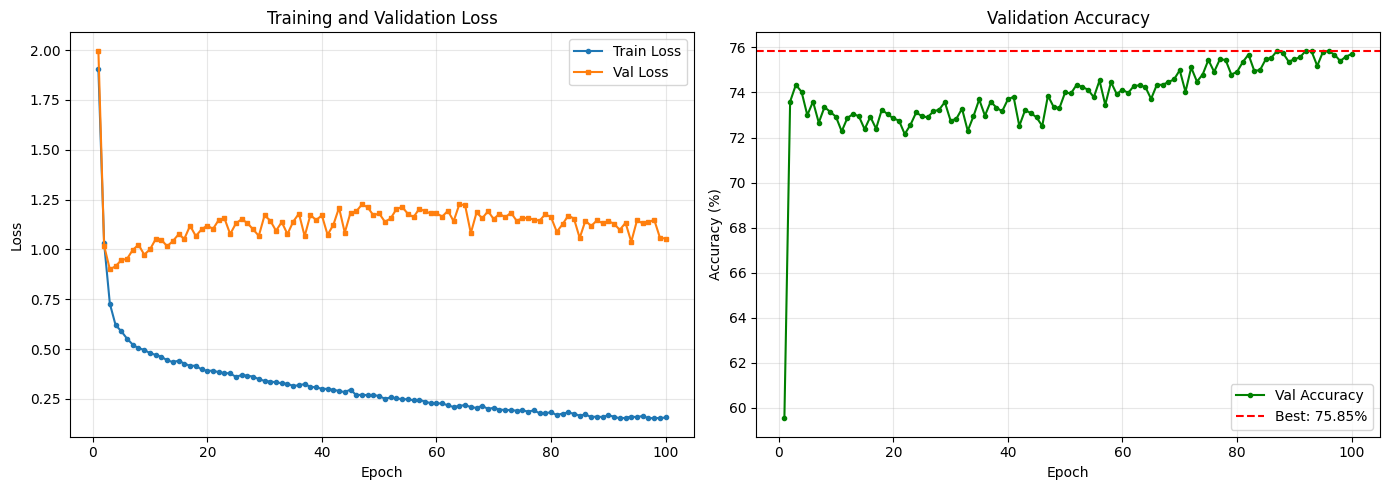

✓ Training plots saved to: checkpoints\training_results.png

TRAINING SUMMARY
Total epochs: 100
Best validation accuracy: 75.85%
Final training loss: 0.1565
Final validation loss: 1.0538
Final validation accuracy: 75.71%


In [25]:
### 7d. Visualize Training Results

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot losses
epochs_range = range(1, len(train_losses) + 1)
axes[0].plot(epochs_range, train_losses, label='Train Loss', marker='o', markersize=3)
axes[0].plot(epochs_range, val_losses, label='Val Loss', marker='s', markersize=3)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot accuracy
axes[1].plot(epochs_range, val_accs, label='Val Accuracy', marker='o', markersize=3, color='green')
axes[1].axhline(y=best_val_acc, color='r', linestyle='--', label=f'Best: {best_val_acc:.2f}%')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Validation Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(checkpoint_dir / 'training_results.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"✓ Training plots saved to: {checkpoint_dir / 'training_results.png'}")

# Print summary statistics
print("\n" + "=" * 60)
print("TRAINING SUMMARY")
print("=" * 60)
print(f"Total epochs: {num_epochs}")
print(f"Best validation accuracy: {best_val_acc:.2f}%")
print(f"Final training loss: {train_losses[-1]:.4f}")
print(f"Final validation loss: {val_losses[-1]:.4f}")
print(f"Final validation accuracy: {val_accs[-1]:.2f}%")
print("=" * 60)


### Loading and Using the Trained Model

After training, you can load the saved model for inference:

```python
# Load the best checkpoint
checkpoint = torch.load("checkpoints/best_model_acc_XX.XX.pt", map_location=device)
model = ResNet18LayerWiseDistillation(num_classes=num_classes)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

# Inference on a batch
with torch.no_grad():
    logits = model(sample_images)
    probabilities = F.softmax(logits, dim=1)
    predictions = torch.argmax(probabilities, dim=1)
```

**Key Points:**
- The model saves checkpoints every time validation accuracy improves
- Training uses layer-wise self-distillation to regularize the network
- CosineAnnealingLR scheduler with warmup for stable convergence
- Gradient clipping prevents exploding gradients
- Best checkpoint is saved based on validation accuracy
